In [1]:
%load_ext autoreload
%autoreload 2
import helper_functions as hf
from imports import *
import importlib

num_available_cpus = multiprocessing.cpu_count()
print("Number of available CPUs:", num_available_cpus)

torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device =", device)
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

torch.set_num_threads(num_available_cpus)

print("Number of threads:", torch.get_num_threads())
print("Number of interop threads:", torch.get_num_interop_threads())

/nobackup/users/sambt/anaconda3/envs/quak/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of available CPUs: 80
Device = cuda:0
Number of threads: 80
Number of interop threads: 80


# Looking at data

In [2]:
year = 2017
data,unnorm,mass,names = hf.LAPS_train("DATA",year,num_batches=40,Mjj_cut=800,pt_cut=300,sideband=True)
data = hf.normalize_data(data)

In [8]:
mean = np.mean(unnorm,axis=0)
std = np.std(unnorm,axis=0)
with h5py.File("bkgMeanStds/dataSB_{0}.h5".format(year),"w") as f:
    f.create_dataset("mean",data=mean)
    f.create_dataset("std",data=std)

In [9]:
d1,u1,m1,n1 = hf.LAPS_train("QCDBKG",year,num_batches=1,Mjj_cut=800,pt_cut=300)
d1 = hf.normalize_data(d1)

Text(0.5, 0, '$m_{jj}$ [GeV]')

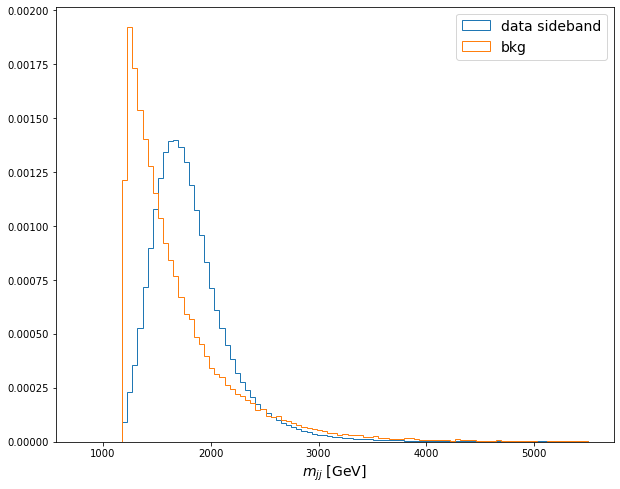

In [10]:
plt.figure(figsize=(10,8))
h1 = plt.hist(mass[:,0],bins=np.linspace(800,5500,num=100),histtype='step',density=True,label='data sideband')
h2 = plt.hist(m1[:,0],bins=np.linspace(800,5500,num=100),histtype='step',density=True,label='bkg')
plt.legend(loc='upper right',fontsize=14)
plt.xlabel(r'$m_{jj}$ [GeV]',fontsize=14)

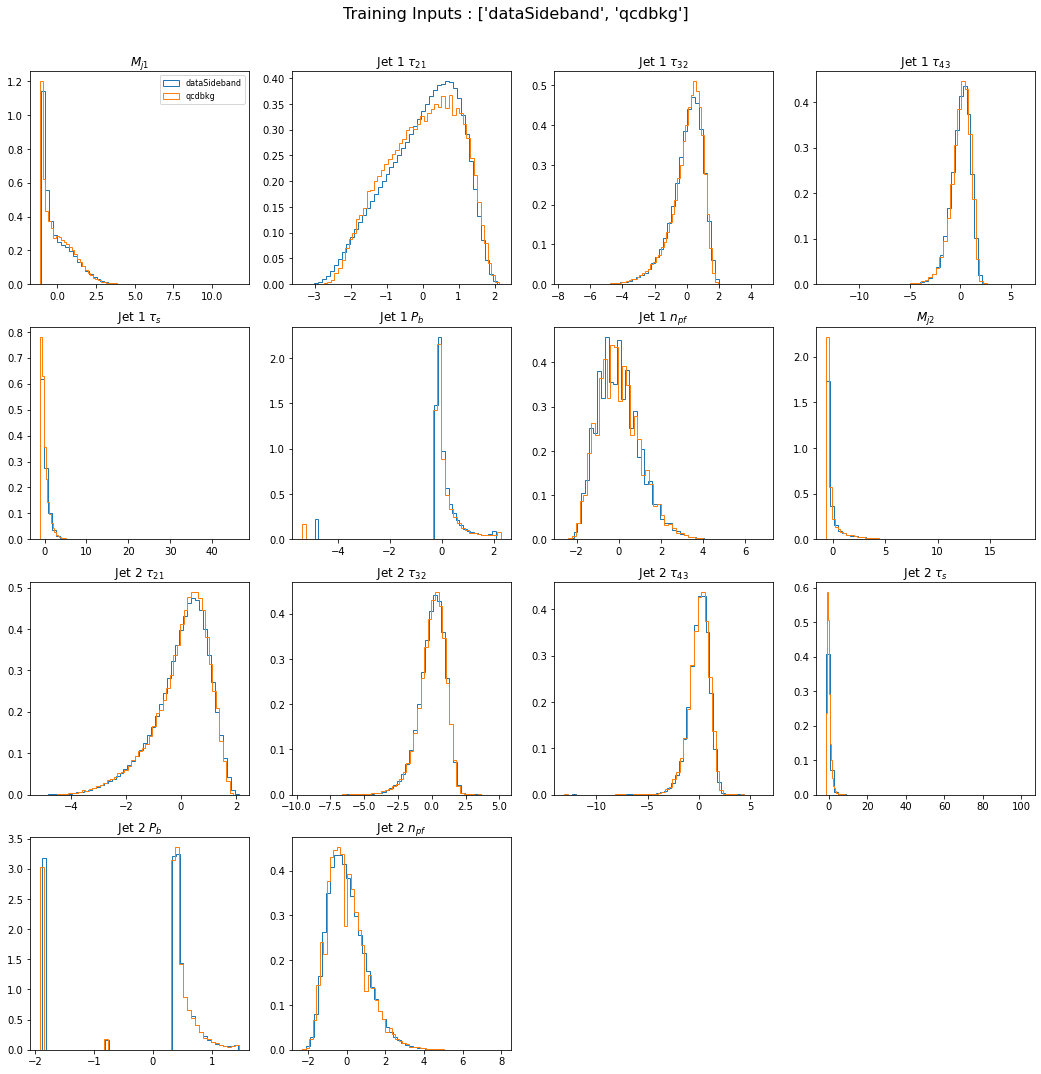

In [11]:
hf.plot_input_variables([data,d1],["dataSideband","qcdbkg"],names,save=False)

# Training

In [3]:
train_params = {"flow_type":"NSRATQUAD","tail_bound":10,"hidden_features":120,"num_layers":6,"num_blocks_per_layer":4,
                "clip":10,"patience":20,"learning_rate":2e-5,"save_model":True,"bs":10000,"nmax":100000}

In [4]:
# split data into train and test
train_data = data[:100000]
test_data = data[100000:]

Initial: 100000 events 
Final: 99958 events 
Removed 0.0420%
Device = cuda:0
FCNN Hidden Layer Width:  120
------------------------------------
Loss:  57.125225
Loss:  49.362007
Loss:  43.286747
Loss:  38.809444
Loss:  35.79879
Loss:  32.7736
Loss:  31.320227
Loss:  29.626444
Loss:  28.229998
Loss:  27.35493
Loss:  26.316046
Loss:  25.36036
Loss:  24.49582
Loss:  24.191984
Loss:  23.710993
Loss:  23.303267
Loss:  22.753586
Loss:  22.260817
Loss:  22.045334
Iteration 20 Complete
Loss:  21.655844
SAVING MODEL
Time:  26.00988459587097
------------------------------------
Loss:  21.159845
Loss:  20.805815
Loss:  20.560715
Loss:  20.39294
Loss:  19.927599
Loss:  19.772871
Loss:  19.512897
Loss:  19.19499
Loss:  19.029016
Loss:  18.863873
Loss:  18.671345
Loss:  18.541172
Loss:  18.226273
Loss:  18.231386
Loss:  18.00986
Loss:  17.77959
Loss:  17.636288
Loss:  17.516777
Loss:  17.48514
Iteration 40 Complete
Loss:  17.282331
SAVING MODEL
Time:  51.75067353248596
------------------------------

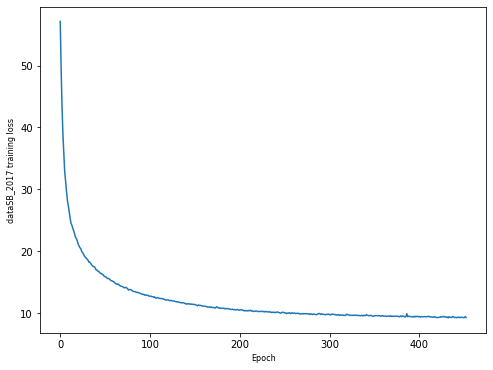

In [29]:
flow = hf.train_pipeline("dataSB_{0}".format(year),train_data,names,train_params,pt_cut=300,Mjj_cut=800)

# Assess training performance

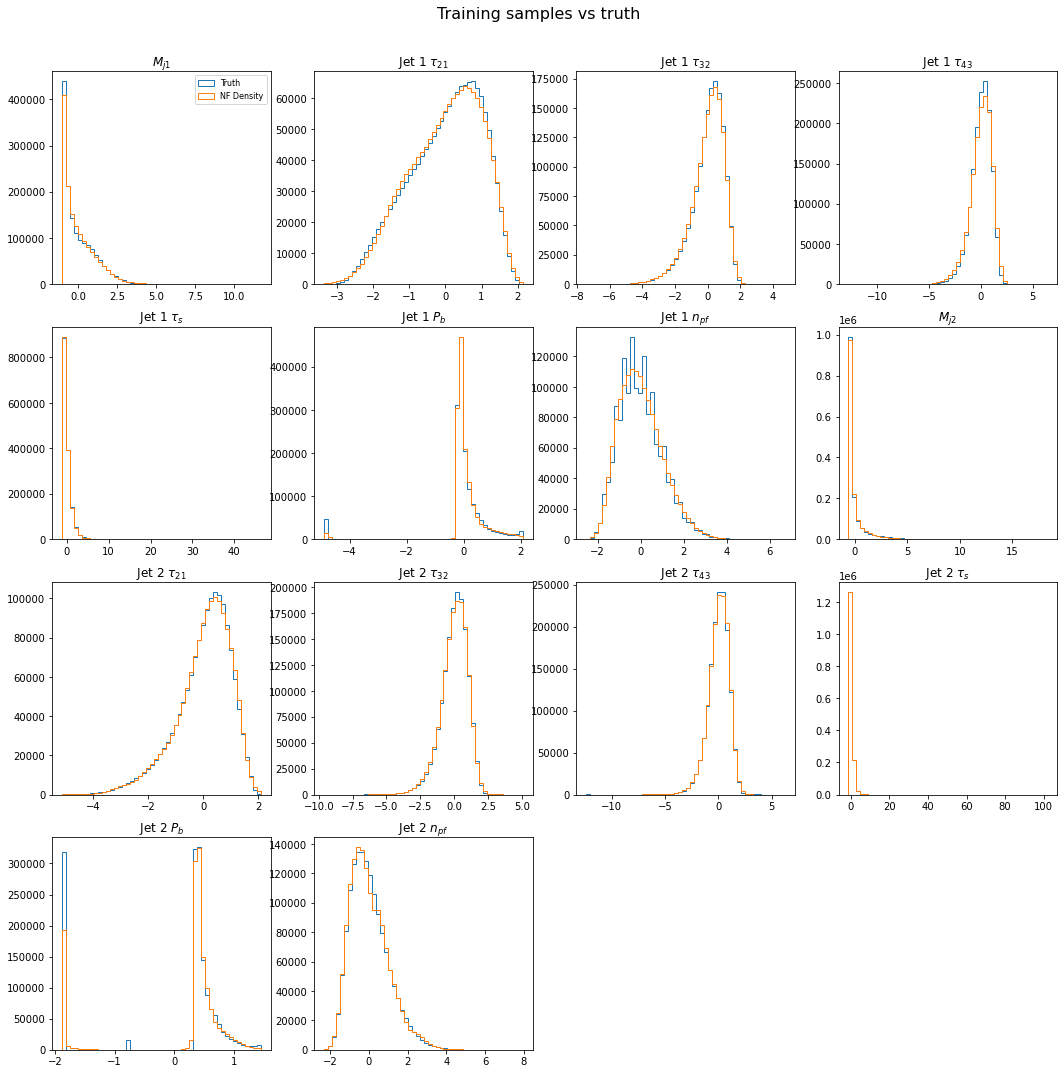

In [6]:
flow = hf.load_model(name="dataSB_{0}_clip10_NSRATQUAD_k6_hf120_nbpl4_tb10_pt300.pt".format(year))
hf.plot_density_estimation(flow,test_data,names)